# Kernel PLS + LDA/QDA Classification

This notebook isolates the nonlinear classification benchmark so the main examples notebook stays compact. It compares raw-space LDA/QDA with KernelPLS features, tuning RBF gamma separately for LDA and QDA.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from missing_methods import get_class_colors
from missing_methods.lda import lda, plot_lda_regions
from missing_methods.qda import qda, plot_qda_regions, plot_qda_boundary_segments
from missing_methods.sk import KernelPLSRegressor

## Function definitions
Dataset generation, train/test splitting, accuracy scoring and gamma tuning.

In [2]:
# Dataset generation
def make_spiral_dataset(n_per_class=80, noise=0.20, n_classes=3, seed=42):
    rng_local = np.random.default_rng(seed)
    X_list = []
    y_list = []
    for cls in range(n_classes):
        t = np.linspace(0.6, 3.5, n_per_class)
        angle = t * 2.2 + cls * (2.0 * np.pi / n_classes)
        x = t * np.cos(angle) + rng_local.normal(scale=noise, size=n_per_class)
        y = t * np.sin(angle) + rng_local.normal(scale=noise, size=n_per_class)
        X_list.append(np.column_stack([x, y]))
        y_list.append(np.full(n_per_class, cls, dtype=int))
    X = np.vstack(X_list)
    y = np.concatenate(y_list)
    return X, y

def split_train_test(X, y, train_fraction=0.7, seed=0):
    idx = np.random.default_rng(seed).permutation(X.shape[0])
    n_train = int(train_fraction * X.shape[0])
    train_idx = idx[:n_train]
    test_idx = idx[n_train:]
    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]

def accuracy(y_true, y_pred):
    return float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))

def padded_limits(X, pad=0.08):
    x0 = float(np.min(X[:, 0]))
    x1 = float(np.max(X[:, 0]))
    y0 = float(np.min(X[:, 1]))
    y1 = float(np.max(X[:, 1]))
    dx = max(1e-9, x1 - x0)
    dy = max(1e-9, y1 - y0)
    return (x0 - pad * dx, x1 + pad * dx), (y0 - pad * dy, y1 + pad * dy)

# Estiamating a data-scaled RBF gamma grid and tuning it for LDA/QDA 
# with KernelPLSRegressor.
def estimate_gamma_grid(X, n_values=13, spread_log10=2.0):
    # Build a data-scaled RBF gamma grid from the median pairwise squared distance.
    X = np.asarray(X, dtype=float)
    sq_dist = np.sum((X[:, None, :] - X[None, :, :]) ** 2, axis=2)
    upper = sq_dist[np.triu_indices_from(sq_dist, k=1)]
    upper = upper[upper > 1e-12]
    if upper.size == 0:
        base_gamma = 1.0 / max(1, X.shape[1])
    else:
        base_gamma = 1.0 / float(np.median(upper))
    multipliers = np.logspace(-spread_log10, spread_log10, n_values)
    return base_gamma * multipliers

def tune_gamma_for_lda(
    X_train,
    y_train,
    *,
    gamma_grid,
    n_components=2,
    val_fraction=0.25,
    impute_ncomp=0.9,
    split_seed=0,
):
    X_sub, y_sub, X_val, y_val = split_train_test(
        X_train,
        y_train,
        train_fraction=1.0 - val_fraction,
        seed=split_seed,
    )
    Y_sub = np.eye(np.unique(y_sub).size)[y_sub]

    best_gamma = float(gamma_grid[0])
    best_score = -np.inf
    gamma_scores = {}

    # Tune gamma by fitting KernelPLS on a sub-train split and scoring LDA on validation data.
    for gamma in gamma_grid:
        kpls = KernelPLSRegressor(n_components=n_components, gamma=float(gamma))
        kpls.fit(X_sub, Y_sub)
        T_sub = kpls.transform(X_sub)
        T_val = kpls.transform(X_val)
        lda_val = lda(T_sub, y_sub, X_new=T_val, impute_ncomp=impute_ncomp)
        score = accuracy(y_val, lda_val["new_fitted"])
        gamma_scores[float(gamma)] = score
        if score > best_score:
            best_score = score
            best_gamma = float(gamma)

    return best_gamma, gamma_scores

def tune_gamma_for_qda(
    X_train,
    y_train,
    *,
    gamma_grid,
    n_components=2,
    val_fraction=0.25,
    impute_ncomp=0.9,
    split_seed=0,
):
    X_sub, y_sub, X_val, y_val = split_train_test(
        X_train,
        y_train,
        train_fraction=1.0 - val_fraction,
        seed=split_seed,
    )
    Y_sub = np.eye(np.unique(y_sub).size)[y_sub]

    best_gamma = float(gamma_grid[0])
    best_score = -np.inf
    gamma_scores = {}

    # Same tuning flow as LDA, but optimize QDA accuracy on the validation split.
    for gamma in gamma_grid:
        kpls = KernelPLSRegressor(n_components=n_components, gamma=float(gamma))
        kpls.fit(X_sub, Y_sub)
        T_sub = kpls.transform(X_sub)
        T_val = kpls.transform(X_val)
        qda_val = qda(T_sub, y_sub, X_new=T_val, impute_ncomp=impute_ncomp)
        score = accuracy(y_val, qda_val["new_fitted"])
        gamma_scores[float(gamma)] = score
        if score > best_score:
            best_score = score
            best_gamma = float(gamma)

    return best_gamma, gamma_scores

## Raw data plot example

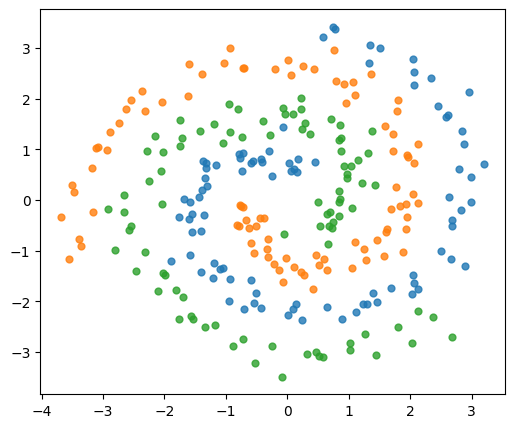

In [3]:
# Plot example of spiral dataset before any analysis.
X_demo, y_demo = make_spiral_dataset(n_per_class=90, noise=0.20, n_classes=3, seed=77_777)

fig, ax = plt.subplots(figsize=(6, 5))
class_colors = get_class_colors(n_classes=np.unique(y_demo).size)
for idx, cls in enumerate(np.unique(y_demo)):
    mask = y_demo == cls
    ax.scatter(
        X_demo[mask, 0],
        X_demo[mask, 1],
        s=24,
        alpha=0.8,
        color=class_colors[idx],
        label=f"Class {cls}",
    )

## Add LDA and QDA regions

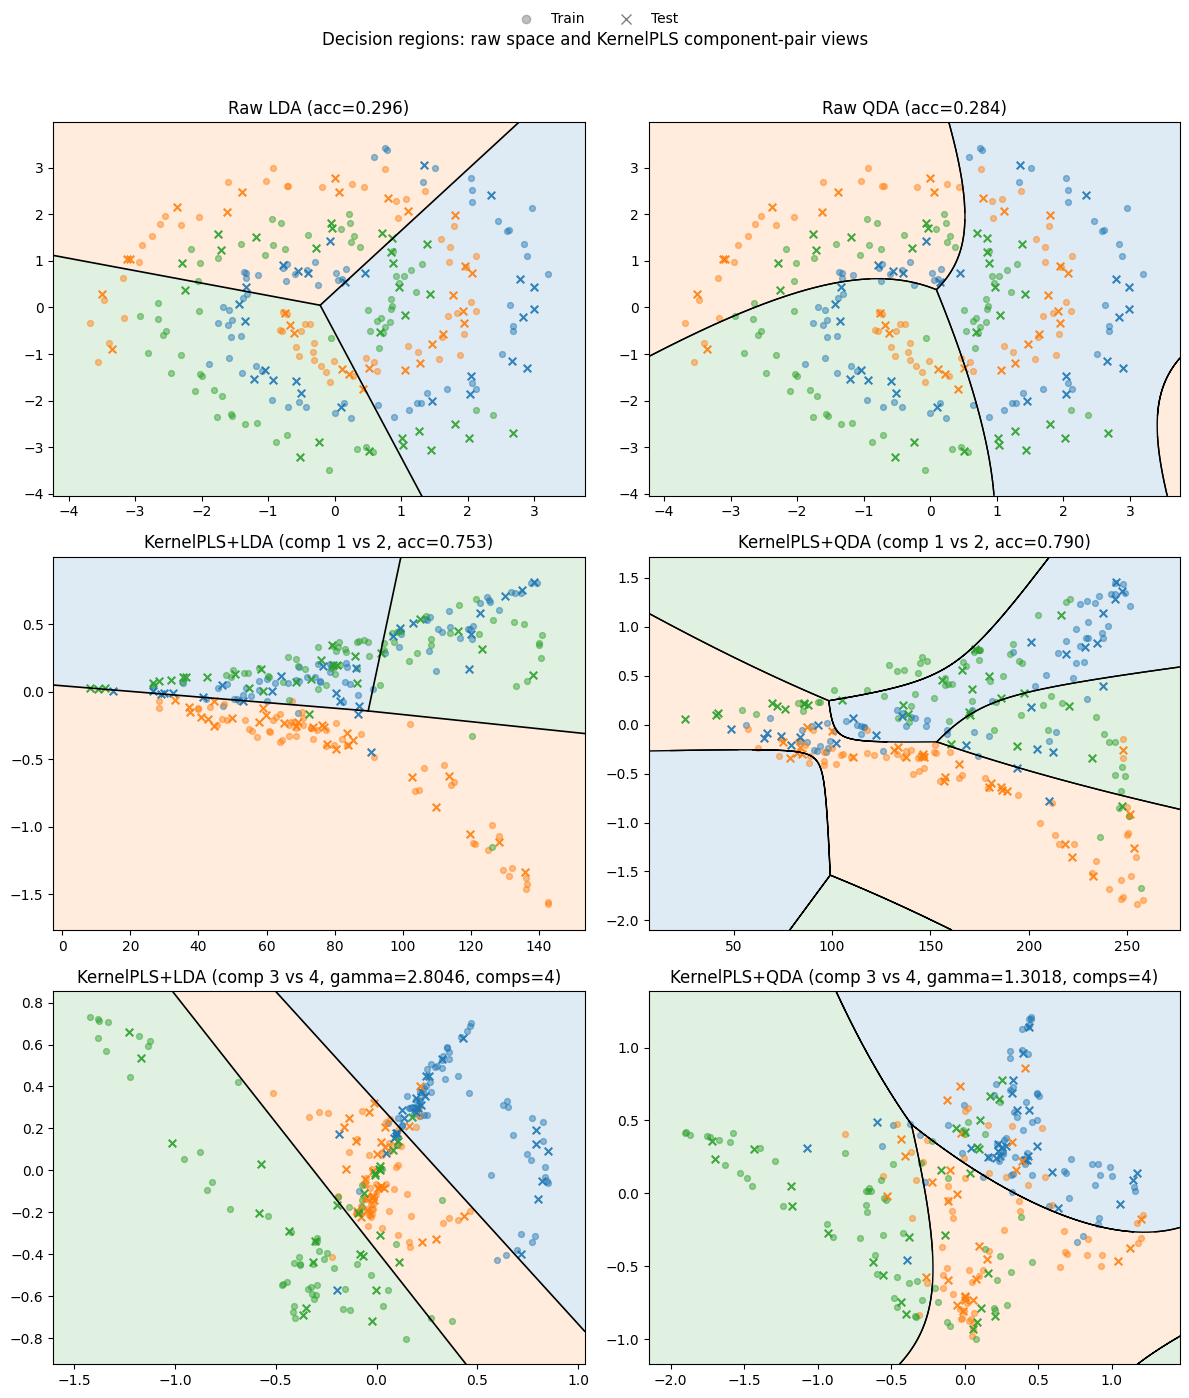

In [7]:
# Number of KernelPLS components to compute
kpls_components = 4
gamma_spread_log10 = 5.0

X_train_d, y_train_d, X_test_d, y_test_d = split_train_test(
    X_demo,
    y_demo,
    train_fraction=0.7,
    seed=88_888,
)

# Tune gamma separately on this fixed split to visualize representative boundaries.
gamma_grid_demo = estimate_gamma_grid(X_train_d, n_values=31, spread_log10=gamma_spread_log10)
gamma_lda_demo, _ = tune_gamma_for_lda(
    X_train_d,
    y_train_d,
    gamma_grid=gamma_grid_demo,
    n_components=kpls_components,
    split_seed=99_999,
)
gamma_qda_demo, _ = tune_gamma_for_qda(
    X_train_d,
    y_train_d,
    gamma_grid=gamma_grid_demo,
    n_components=kpls_components,
    split_seed=111_111,
)

lda_raw_d = lda(X_train_d, y_train_d, X_new=X_test_d, impute_ncomp=0.9)
qda_raw_d = qda(X_train_d, y_train_d, X_new=X_test_d, impute_ncomp=0.9)
acc_lda_raw_d = accuracy(y_test_d, lda_raw_d["new_fitted"])
acc_qda_raw_d = accuracy(y_test_d, qda_raw_d["new_fitted"])

Y_train_d = np.eye(np.unique(y_train_d).size)[y_train_d]

kpls_lda_d = KernelPLSRegressor(n_components=kpls_components, gamma=gamma_lda_demo)
kpls_lda_d.fit(X_train_d, Y_train_d)
T_train_lda_d = kpls_lda_d.transform(X_train_d)
T_test_lda_d = kpls_lda_d.transform(X_test_d)

kpls_qda_d = KernelPLSRegressor(n_components=kpls_components, gamma=gamma_qda_demo)
kpls_qda_d.fit(X_train_d, Y_train_d)
T_train_qda_d = kpls_qda_d.transform(X_train_d)
T_test_qda_d = kpls_qda_d.transform(X_test_d)

lda_kpls_d = lda(T_train_lda_d, y_train_d, X_new=T_test_lda_d, impute_ncomp=0.9)
qda_kpls_d = qda(T_train_qda_d, y_train_d, X_new=T_test_qda_d, impute_ncomp=0.9)
acc_lda_kpls_d = accuracy(y_test_d, lda_kpls_d["new_fitted"])
acc_qda_kpls_d = accuracy(y_test_d, qda_kpls_d["new_fitted"])

def component_pair_projection(n_components: int, c1: int, c2: int) -> np.ndarray:
    # Select two latent components by projecting them directly to x/y axes.
    proj = np.zeros((n_components, 2), dtype=float)
    proj[c1, 0] = 1.0
    proj[c2, 1] = 1.0
    return proj

pair_12 = component_pair_projection(kpls_components, 0, 1)
pair_34 = component_pair_projection(kpls_components, 2, 3)

fig, axes = plt.subplots(3, 2, figsize=(12, 14))
class_colors = get_class_colors(len(np.unique(y_demo)))

xlim_raw, ylim_raw = padded_limits(np.vstack([X_train_d, X_test_d]))
plot_lda_regions(
    lda_raw_d,
    ax=axes[0, 0],
    xlim=xlim_raw,
    ylim=ylim_raw,
    alpha=0.14,
    draw_segments=True,
    line_kwargs={"color": "black", "linewidth": 1.2},
    class_colors=class_colors,
    train_X=X_train_d,
    train_y=y_train_d,
    test_X=X_test_d,
    test_y=y_test_d,
)
axes[0, 0].set_title(f"Raw LDA (acc={acc_lda_raw_d:.3f})")

plot_qda_regions(
    qda_raw_d,
    ax=axes[0, 1],
    xlim=xlim_raw,
    ylim=ylim_raw,
    alpha=0.14,
    draw_pairwise=False,
    class_colors=class_colors,
    train_X=X_train_d,
    train_y=y_train_d,
    test_X=X_test_d,
    test_y=y_test_d,
)
plot_qda_boundary_segments(
    qda_raw_d,
    ax=axes[0, 1],
    xlim=xlim_raw,
    ylim=ylim_raw,
    n_samples=900,
    line_kwargs={"color": "black", "linewidth": 1.0},
)
axes[0, 1].set_title(f"Raw QDA (acc={acc_qda_raw_d:.3f})")

# Rows 2 and 3: same models, different latent component pairs for interpretability.
plot_lda_regions(
    lda_kpls_d,
    ax=axes[1, 0],
    alpha=0.14,
    draw_segments=True,
    projection_matrix=pair_12,
    line_kwargs={"color": "black", "linewidth": 1.2},
    class_colors=class_colors,
    train_X=T_train_lda_d,
    train_y=y_train_d,
    test_X=T_test_lda_d,
    test_y=y_test_d,
)
axes[1, 0].set_title(f"KernelPLS+LDA (comp 1 vs 2, acc={acc_lda_kpls_d:.3f})")

plot_qda_regions(
    qda_kpls_d,
    ax=axes[1, 1],
    alpha=0.14,
    draw_pairwise=False,
    projection_matrix=pair_12,
    class_colors=class_colors,
    train_X=T_train_qda_d,
    train_y=y_train_d,
    test_X=T_test_qda_d,
    test_y=y_test_d,
)
plot_qda_boundary_segments(
    qda_kpls_d,
    ax=axes[1, 1],
    projection_matrix=pair_12,
    xlim=axes[1, 1].get_xlim(),
    ylim=axes[1, 1].get_ylim(),
    n_samples=900,
    line_kwargs={"color": "black", "linewidth": 1.0},
)
axes[1, 1].set_title(f"KernelPLS+QDA (comp 1 vs 2, acc={acc_qda_kpls_d:.3f})")

plot_lda_regions(
    lda_kpls_d,
    ax=axes[2, 0],
    alpha=0.14,
    draw_segments=True,
    projection_matrix=pair_34,
    line_kwargs={"color": "black", "linewidth": 1.2},
    class_colors=class_colors,
    train_X=T_train_lda_d,
    train_y=y_train_d,
    test_X=T_test_lda_d,
    test_y=y_test_d,
)
axes[2, 0].set_title(f"KernelPLS+LDA (comp 3 vs 4, gamma={gamma_lda_demo:.4f}, comps={kpls_components})")

plot_qda_regions(
    qda_kpls_d,
    ax=axes[2, 1],
    alpha=0.14,
    draw_pairwise=False,
    projection_matrix=pair_34,
    class_colors=class_colors,
    train_X=T_train_qda_d,
    train_y=y_train_d,
    test_X=T_test_qda_d,
    test_y=y_test_d,
)
plot_qda_boundary_segments(
    qda_kpls_d,
    ax=axes[2, 1],
    projection_matrix=pair_34,
    xlim=axes[2, 1].get_xlim(),
    ylim=axes[2, 1].get_ylim(),
    n_samples=900,
    line_kwargs={"color": "black", "linewidth": 1.0},
)
axes[2, 1].set_title(f"KernelPLS+QDA (comp 3 vs 4, gamma={gamma_qda_demo:.4f}, comps={kpls_components})")

legend_handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", markersize=6, markerfacecolor="gray", alpha=0.5, color="gray", label="Train"),
    plt.Line2D([0], [0], marker="x", linestyle="", markersize=7, color="gray", label="Test"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=2, frameon=False)
fig.suptitle("Decision regions: raw space and KernelPLS component-pair views", y=0.98)
plt.tight_layout(rect=(0, 0, 1, 0.965))
plt.show()

## Confusion matrix and diagnostics

In [5]:
# Diagnostic: compare full latent-space and plotted 2-D behavior.
# This makes it explicit whether a visual mismatch is a plotting bug or model geometry.

def confusion_matrix_simple(y_true, y_pred, classes):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    classes = np.asarray(classes)
    cm = np.zeros((classes.size, classes.size), dtype=int)
    for i, ci in enumerate(classes):
        for j, cj in enumerate(classes):
            cm[i, j] = int(np.sum((y_true == ci) & (y_pred == cj)))
    return cm

classes_demo = np.unique(y_train_d)

# LDA projected to 2D for plotting.
lda_plot_train = lda_kpls_d["filled_X"]
lda_plot_test = lda_kpls_d["new_filled_X"]
lda_plot_model = lda(lda_plot_train, y_train_d, X_new=lda_plot_test, impute_ncomp=0.9)
acc_lda_plot2d = accuracy(y_test_d, lda_plot_model["new_fitted"])
acc_lda_train = accuracy(y_train_d, lda_kpls_d["fitted"])

# QDA projected to 2D for plotting.
qda_plot_train = qda_kpls_d["filled_X"]
qda_plot_test = qda_kpls_d["new_filled_X"]
qda_plot_model = qda(qda_plot_train, y_train_d, X_new=qda_plot_test, impute_ncomp=0.9)
acc_qda_plot2d = accuracy(y_test_d, qda_plot_model["new_fitted"])
acc_qda_train = accuracy(y_train_d, qda_kpls_d["fitted"])

# Agreement between full-space and projected-space model predictions.
agreement_lda = accuracy(lda_kpls_d["new_fitted"], lda_plot_model["new_fitted"])
agreement_qda = accuracy(qda_kpls_d["new_fitted"], qda_plot_model["new_fitted"])

print(f"LDA train acc={acc_lda_train:.3f} | full-space test acc={acc_lda_kpls_d:.3f} | plotted-2D test acc={acc_lda_plot2d:.3f} | agreement={agreement_lda:.3f}")
print(f"QDA train acc={acc_qda_train:.3f} | full-space test acc={acc_qda_kpls_d:.3f} | plotted-2D test acc={acc_qda_plot2d:.3f} | agreement={agreement_qda:.3f}")

cm_qda = confusion_matrix_simple(y_test_d, qda_kpls_d["new_fitted"], classes_demo)
print("QDA test confusion matrix (rows=true, cols=pred):")
print(cm_qda)

LDA train acc=0.931 | full-space test acc=0.765 | plotted-2D test acc=0.765 | agreement=1.000
QDA train acc=0.878 | full-space test acc=0.790 | plotted-2D test acc=0.790 | agreement=1.000
QDA test confusion matrix (rows=true, cols=pred):
[[19  4  3]
 [ 1 26  1]
 [ 8  0 19]]


## Repeated data sampling and fitting
Check performance of classifiers when data varies slightly

Raw LDA                            mean=0.315  std=0.044
Raw QDA                            mean=0.317  std=0.045
KernelPLS(tuned LDA) + LDA         mean=0.864  std=0.078
KernelPLS(tuned QDA) + QDA         mean=0.824  std=0.051
Chosen gamma (LDA): median=6.0271, min=0.8599, max=6.3816
Chosen gamma (QDA): median=0.9026, min=0.8599, max=6.3816
KernelPLS components used: 4
Gamma spread log10 used: 5.0


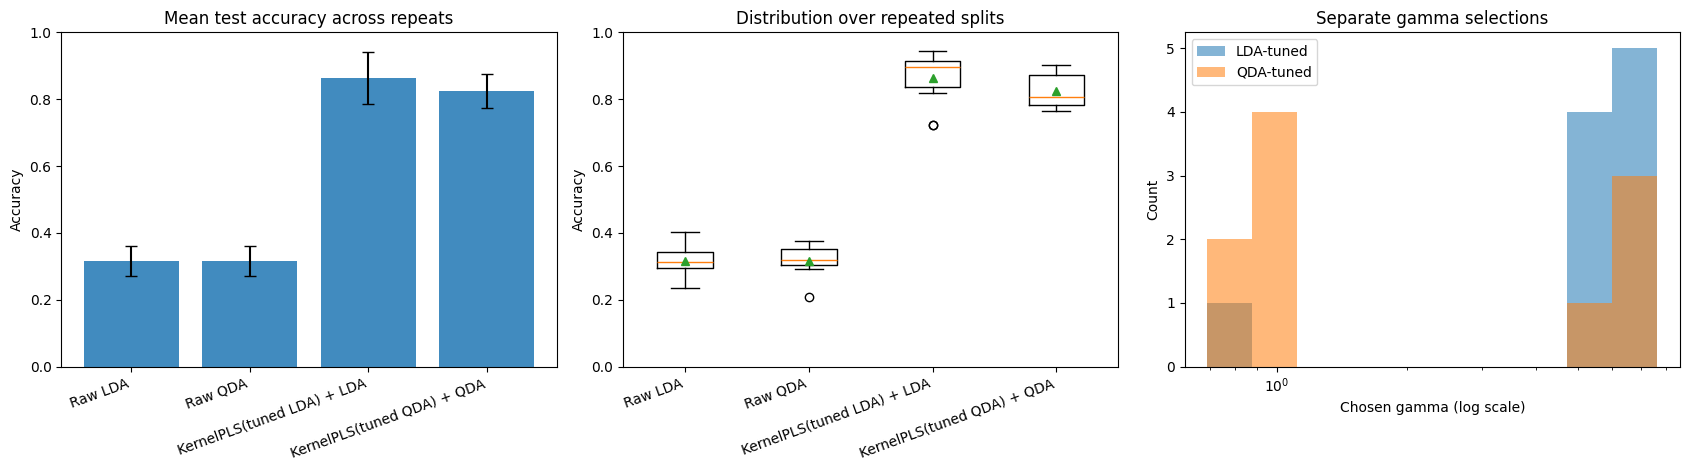

In [6]:
n_repeats = 10

results = np.zeros((n_repeats, 4), dtype=float)
chosen_gammas_lda = np.zeros(n_repeats, dtype=float)
chosen_gammas_qda = np.zeros(n_repeats, dtype=float)

# Repeated split benchmark: raw models vs KernelPLS features with separately tuned gamma.
for rep in range(n_repeats):
    dataset_seed = 10_000 + rep
    split_seed = 20_000 + rep
    tune_seed_lda = 30_000 + rep
    tune_seed_qda = 40_000 + rep

    X_all, y_all = make_spiral_dataset(seed=dataset_seed)
    X_train, y_train, X_test, y_test = split_train_test(
        X_all,
        y_all,
        train_fraction=0.7,
        seed=split_seed,
    )

    gamma_grid = estimate_gamma_grid(X_train, n_values=13, spread_log10=gamma_spread_log10)

    lda_raw = lda(X_train, y_train, X_new=X_test, impute_ncomp=0.9)
    qda_raw = qda(X_train, y_train, X_new=X_test, impute_ncomp=0.9)

    best_gamma_lda, _ = tune_gamma_for_lda(
        X_train,
        y_train,
        gamma_grid=gamma_grid,
        n_components=kpls_components,
        split_seed=tune_seed_lda,
    )
    best_gamma_qda, _ = tune_gamma_for_qda(
        X_train,
        y_train,
        gamma_grid=gamma_grid,
        n_components=kpls_components,
        split_seed=tune_seed_qda,
    )
    chosen_gammas_lda[rep] = best_gamma_lda
    chosen_gammas_qda[rep] = best_gamma_qda

    Y_train = np.eye(np.unique(y_train).size)[y_train]

    # Fit two separate KernelPLS projections so each downstream classifier uses its own tuned gamma.
    kpls_lda = KernelPLSRegressor(n_components=kpls_components, gamma=best_gamma_lda)
    kpls_lda.fit(X_train, Y_train)
    T_train_lda = kpls_lda.transform(X_train)
    T_test_lda = kpls_lda.transform(X_test)

    kpls_qda = KernelPLSRegressor(n_components=kpls_components, gamma=best_gamma_qda)
    kpls_qda.fit(X_train, Y_train)
    T_train_qda = kpls_qda.transform(X_train)
    T_test_qda = kpls_qda.transform(X_test)

    lda_kpls = lda(T_train_lda, y_train, X_new=T_test_lda, impute_ncomp=0.9)
    qda_kpls = qda(T_train_qda, y_train, X_new=T_test_qda, impute_ncomp=0.9)

    results[rep, 0] = accuracy(y_test, lda_raw["new_fitted"])
    results[rep, 1] = accuracy(y_test, qda_raw["new_fitted"])
    results[rep, 2] = accuracy(y_test, lda_kpls["new_fitted"])
    results[rep, 3] = accuracy(y_test, qda_kpls["new_fitted"])

labels = [
    "Raw LDA",
    "Raw QDA",
    "KernelPLS(tuned LDA) + LDA",
    "KernelPLS(tuned QDA) + QDA",
]

mean_scores = results.mean(axis=0)
std_scores = results.std(axis=0)

for idx, label in enumerate(labels):
    print(f"{label:34s} mean={mean_scores[idx]:.3f}  std={std_scores[idx]:.3f}")
print(
    f"Chosen gamma (LDA): median={np.median(chosen_gammas_lda):.4f}, min={chosen_gammas_lda.min():.4f}, max={chosen_gammas_lda.max():.4f}"
)
print(
    f"Chosen gamma (QDA): median={np.median(chosen_gammas_qda):.4f}, min={chosen_gammas_qda.min():.4f}, max={chosen_gammas_qda.max():.4f}"
)
print(f"KernelPLS components used: {kpls_components}")
print(f"Gamma spread log10 used: {gamma_spread_log10}")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

xpos = np.arange(len(labels))
axes[0].bar(xpos, mean_scores, yerr=std_scores, capsize=4, alpha=0.85)
axes[0].set_xticks(xpos)
axes[0].set_xticklabels(labels, rotation=20, ha="right")
axes[0].set_ylim(0.0, 1.0)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Mean test accuracy across repeats")

axes[1].boxplot([results[:, i] for i in range(results.shape[1])], tick_labels=labels, showmeans=True)
axes[1].set_xticklabels(labels, rotation=20, ha="right")
axes[1].set_ylim(0.0, 1.0)
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Distribution over repeated splits")

# Use log-spaced bins so both small and large tuned gamma values remain visible.
bins = np.geomspace(
    max(1e-6, min(chosen_gammas_lda.min(), chosen_gammas_qda.min()) * 0.8),
    max(chosen_gammas_lda.max(), chosen_gammas_qda.max()) * 1.2,
    11,
)
axes[2].hist(chosen_gammas_lda, bins=bins, alpha=0.55, label="LDA-tuned")
axes[2].hist(chosen_gammas_qda, bins=bins, alpha=0.55, label="QDA-tuned")
axes[2].set_xscale("log")
axes[2].set_xlabel("Chosen gamma (log scale)")
axes[2].set_ylabel("Count")
axes[2].set_title("Separate gamma selections")
axes[2].legend()

plt.tight_layout()
plt.show()